# Recalculating Ekman Cross-shore

* For the Ekman Cross-shore ($Ek_{c}$) we need to grab the offshore boundary.
* Let's give the distance from the coast to the boundary as $L$

## We make some Assumptions

* Alongshore wind stress drives cross-shore Ekman transport in the surface boundary layer of depth δE
* Coordinates: x is offshore (positive seaward), y is alongshore, z is vertical upward with z=0 at the surface and z=−δE at the Ekman base.
* Steady, Boussinesq, hydrostatic, horizontally uniform along y, negligible alongshore pressure gradient within the Ekman layer.
* No vertical turbulent stress at the Ekman base: τy(z=−δE)=0; at surface: τy(z=0)=τy0.
* No-normal-flow at the coast (x=0): u=0. The offshore boundary is at x=L, where the Ekman layer outcrops into the interior; w(x=L, z=−δE)=0.

## Definitions and Assumptions
We consider a surface Ekman layer of depth $\delta_E$.

Coordinates: $x$ offshore, $y$ alongshore, $z$ upward with $z=0$ at the surface and $z=-\delta_E$ at the Ekman base.

Surface stress $\tau_y(0)=\tau_{y0}$, and $\tau_y(-\delta_E)=0$.

Assume steady Boussinesq flow and $w(0)=0$ (after removing surface waves).

## Ekman transport for momentum balance

$$
fu \;=\; \frac{1}{\rho}\,\frac{\partial \tau_y}{\partial z}
$$

Define the transport per unit width
$$
M_E \;\equiv\; \int_{-\delta_E}^{0} u\,dz.
$$

Integrate in $z$:
$$
\int_{-\delta_E}^{0} fu\,dz
= \frac{1}{\rho}\big[\tau_y\big]_{-\delta_E}^{0}
= \frac{\tau_{y0}}{\rho}
\;\;\Rightarrow\;\;
f\,M_E \;=\; \frac{\tau_{y0}}{\rho}
\;\;\Rightarrow\;\;
M_E \;=\; \frac{\tau_{y0}}{\rho f}.
$$

## Continuity and relation to w at the Ekman base

Incompressibility:
$$
\frac{\partial u}{\partial x}+\frac{\partial w}{\partial z}=0.
$$

Integrate from $z=-\delta_E$ to $z=0$:
$$
\frac{\partial}{\partial x}\!\left(\int_{-\delta_E}^{0}u\,dz\right)
+\Big[w\Big]_{-\delta_E}^{0}=0
\;\;\Rightarrow\;\;
\frac{\partial M_E}{\partial x}=w(-\delta_E)-w(0).
$$

With $w(0)=0$:
$$
w(-\delta_E)=\frac{\partial M_E}{\partial x}.
$$

## Coastal control volume and equivalence
Integrate in $x$ from the coast $x=0$ (no-normal-flow $\Rightarrow M_E(0)=0$) to $x=L$:
$$
M_E(L)-M_E(0)=\int_{0}^{L} w(-\delta_E)\,dx
\;\;\Rightarrow\;\;
M_E(L)=\int_{0}^{L} w_b\,dx,
$$
where $w_b\equiv w(-\delta_E)$ and, if approximately uniform over $[0,L]$,
$$
M_E(L)=w_b\,L.
$$

Using $M_E(L)=\dfrac{\tau_{y0}}{\rho f}$ gives
$$
w_b\,L=\frac{\tau_{y0}}{\rho f}
\quad\Rightarrow\quad
\boxed{\,w_b=\dfrac{1}{L}\,\dfrac{\tau_{y0}}{\rho f}\, }.
$$

Then we need to calculate the $Ek_{t}$ at the offshore part of $L$ as it is the equivalent of the $w_b$

Then let $Ek_c$ be:

\begin{equation}
\tau_{\text{alongshore}} = \sin(\alpha)\,\tau_{y} + \cos(\alpha)\,\tau_{x}
\end{equation}

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 
import matplotlib.colors as mcolors

## Functions

In [3]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

/tmp/ipykernel_3339974/3366088229.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


In [4]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [5]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK100km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

## Data

In [ ]:
# import glob

# files = sorted(glob.glob('/gxfs_work/geomar/smomw662/NHCS/Winds_input/Winds_6h/extracted_winds/croco_blk_ERA5_Y*M*_uwnd_vwnd.nc'))
# print(len(files), files[:5], files[-5:])

# # Peek at first two
# for f in files[:3]:
#     with xr.open_dataset(f) as ds:
#         print(f, ds['bulk_time'].load().values[:3], ds['bulk_time'].load().values[-3:])

In [6]:
#--- winds
new_w = loadmat("../../NHCS/Processed/new_winds.mat")

winds_ds = xr.Dataset(
    data_vars={
        'u10': (("time", "lat","lon"), new_w['uwind'].transpose(2, 1, 0)),
        'v10':(("time", "lat","lon"), new_w['vwind'].transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

In [7]:
ws = np.sqrt(winds_ds.u10**2 + winds_ds.v10**2)
omega = 7.29e-5
rho = 1000
f = 2 * omega * np.sin(np.radians(winds_ds.lat))
pa = 1.22
cd = 1.3e-3
taux = pa * cd * ws * winds_ds.u10
tauy = pa * cd * ws * winds_ds.v10


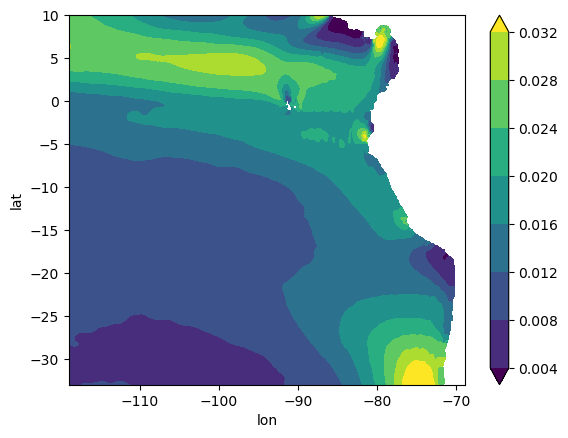

In [8]:
tauy.std('time').plot.contourf(robust=True)
# taux.std('time').plot(robust=True)

In [9]:
rho_sw = 1025

Ek_t = tauy / (rho_sw * f)
Ek_t
# BUI.to_netcdf('BUI.nc')

<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 1GB
array([[[ 0.03266665,  0.0340377 ,  0.03555215, ...,         nan,
                 nan,         nan],
        [ 0.03362432,  0.03509667,  0.03670213, ...,         nan,
                 nan,         nan],
        [ 0.03444884,  0.03603278,  0.03772928, ...,         nan,
                 nan,         nan],
        ...,
        [-0.68738323, -0.68413482, -0.68237435, ...,         nan,
                 nan,         nan],
        [-0.68731079, -0.68420237, -0.68238188, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[ 0.03117438,  0.03342822,  0.03557448, ...,         nan,
                 nan,         nan],
        [ 0.03178854,  0.03393052,  0.03595567, ...,         nan,
                 nan,         nan],
        [ 0.03228048,  0.03428501,  0.03616516, ...,         nan,
                 nan,         nan],
...
        [ 0.00418704,  0.00426369,  0.00431485, ...,         nan,
                 nan,         nan],
        [ 0.0021588 ,  0.00220842,  0.00224361, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[-0.00698454, -0.00634932, -0.00571175, ...,         nan,
                 nan,         nan],
        [-0.00716184, -0.0065457 , -0.00591242, ...,         nan,
                 nan,         nan],
        [-0.00735085, -0.00675525, -0.00612812, ...,         nan,
                 nan,         nan],
        ...,
        [-1.74861965, -1.72391721, -1.70009157, ...,         nan,
                 nan,         nan],
        [-1.80678913, -1.78183841, -1.75756903, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

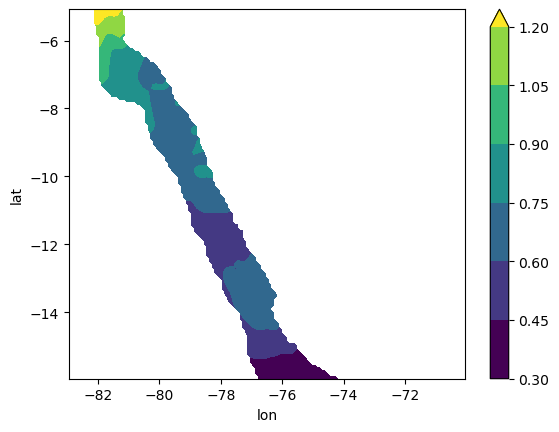

In [10]:
(Ek_t*inshore_mask).sel(lat=slice(-16,-5),lon=slice(-83,-70)).std('time').plot.contourf(robust=True)

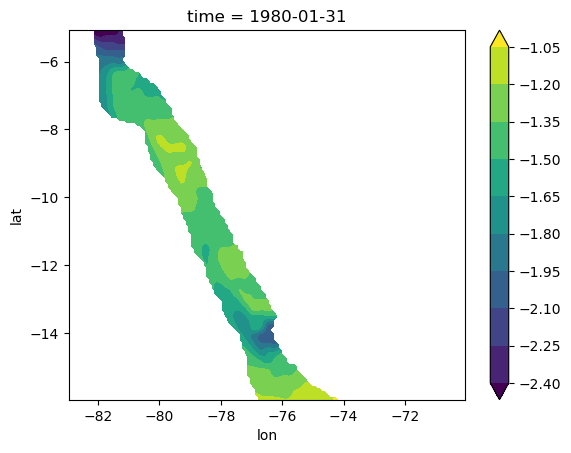

In [11]:
NEk_t = (Ek_t*inshore_mask).sel(lat=slice(-16,-5),lon=slice(-83,-70))
NEk_t.isel(time=0).plot.contourf(robust=True,levels=10)

In [12]:
da = NEk_t.isel(time=0)   # dims: lat, lon

In [13]:
# # Boolean mask of valid ocean cells
# valid = xr.where(np.isfinite(da), 1, 0)

# # Shift mask in 4 directions
# valid_n = valid.shift(lat=-1)  # neighbor to the north
# valid_s = valid.shift(lat=+1)  # south
# valid_e = valid.shift(lon=+1)  # east
# valid_w = valid.shift(lon=-1)  # west

# # A cell is border if:
# #  - it is valid itself
# #  - and at least one neighbor is NaN (0)
# border_mask = (valid == 1) & (
#     (valid_n == 0) | (valid_s == 0) | (valid_e == 0) | (valid_w == 0)
# )

# border_cells = da.where(border_mask)

In [14]:
# border_cells.plot()

In [15]:
# western neighbor of the valid mask
valid = xr.where(np.isfinite(NEk_t), 1, 0)
valid_w = valid.shift(lon=-1)
# Boolean mask of valid ocean cells
valid_in = xr.where(np.isfinite(da), 1, 0)
# valid_e = valid.shift(lon=+1)  # east

inshore_mask0 = (valid_in == 1) & (valid_w == 0)

inshore_border = NEk_t.where(inshore_mask0)

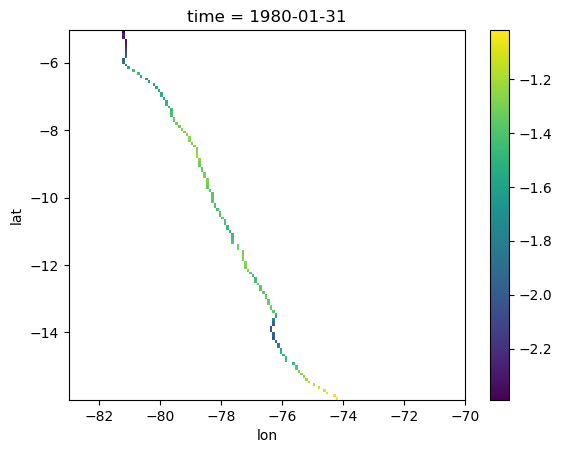

In [16]:
inshore_border.isel(time=0).plot()

### Offshore Ekman transport

In [17]:
valid = xr.where(np.isfinite(NEk_t), 1, 0)
valid_e = valid.shift(lon=+1)  # east

offshore_mask = (valid == 1) & (valid_e == 0)

offshore_border = NEk_t.where(offshore_mask)

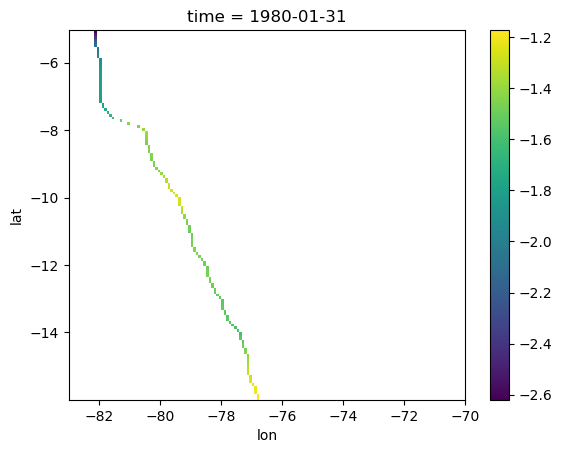

In [18]:
offshore_border.isel(time=0).plot()

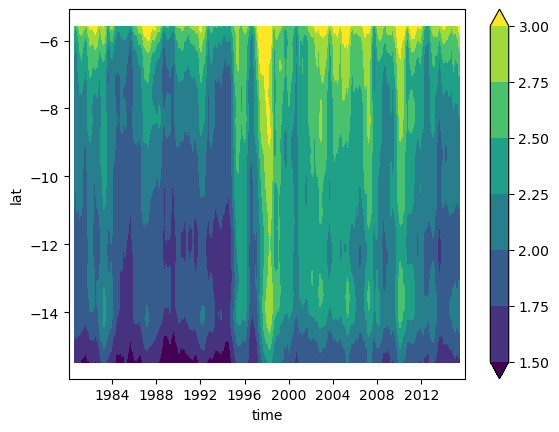

In [19]:
(offshore_border.mean(dim='lon').rolling(time=13,lat=13,center=True).mean()*-1).plot.contourf(x='time',robust=True)

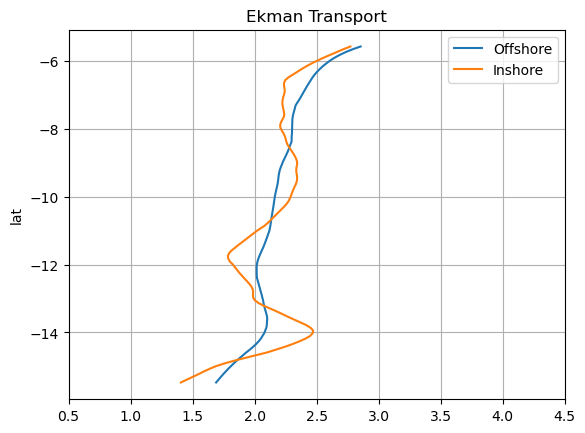

In [20]:
(offshore_border.mean(dim=('lon','time')).rolling(lat=13,center=True).mean()*-1).plot(y='lat',label='Offshore')
(inshore_border.mean(dim=('lon','time')).rolling(lat=13,center=True).mean()*-1).plot(y='lat',label='Inshore')

plt.xlim([0.5 ,4.5])
plt.legend()
plt.title('Ekman Transport')
plt.grid()

In [ ]:
## I can compare them bc the inshore captures the peak of the upwelling

Text(0.5, 1.0, 'Offshore $Ek_t$')

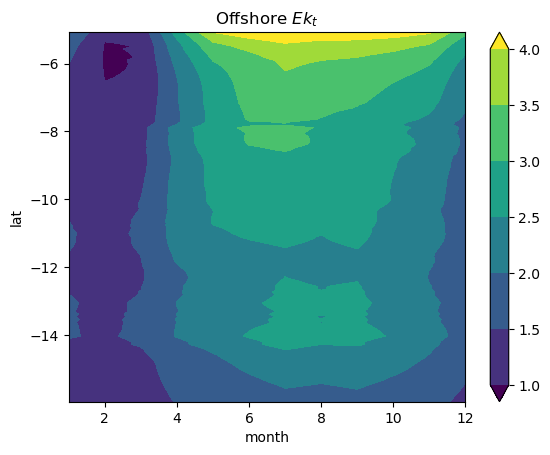

In [21]:
(-seasonality(offshore_border)).mean(dim='lon').plot.contourf(x='month',robust=True)
plt.title('Offshore $Ek_t$')

Text(0.5, 1.0, 'Inshore $Ek_t$')

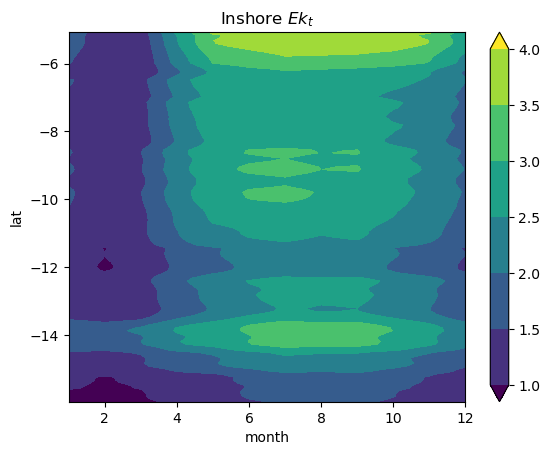

In [22]:
(-seasonality(inshore_border)).mean(dim='lon').plot.contourf(x='month',robust=True)
plt.title('Inshore $Ek_t$')

Text(0.5, 1.0, '$Ek_t$ detrended anomalies')

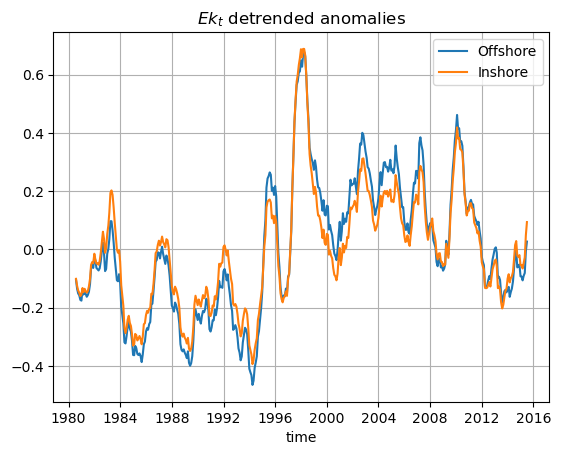

In [23]:
(monthly_anomaly(offshore_border).rolling(time=13,center=True).mean()*-1).plot(label='Offshore')
(monthly_anomaly(inshore_border).rolling(time=13,center=True).mean()*-1).plot(label='Inshore')

plt.grid()
plt.legend()
plt.title('$Ek_t$ detrended anomalies')

Text(0.5, 1.0, '$Ek_t$ detrended')

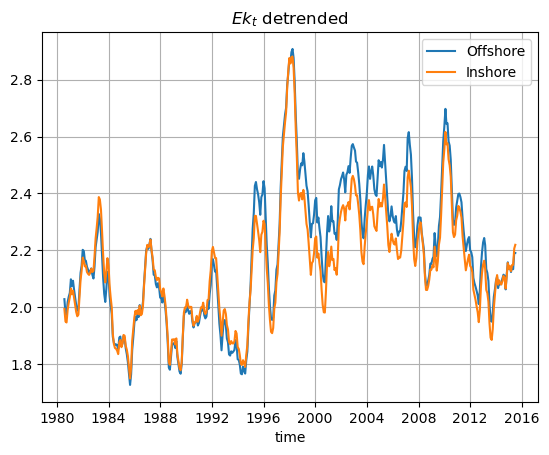

In [24]:
(offshore_border.mean(dim=('lat','lon')).rolling(time=13,center=True).mean()*-1).plot(label='Offshore')
(inshore_border.mean(dim=('lat','lon')).rolling(time=13,center=True).mean()*-1).plot(label='Inshore')

plt.grid()
plt.legend()
plt.title('$Ek_t$ detrended')